## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [26]:
df = pd.read_csv('data/stud.csv')

df = pd.read_excel(r"E:\Cauldron\Artigo Sementes\00_Dados\seed_df_v1.xlsx")

#### Show Top 5 Records

In [27]:
df.head()

,Sem.,Area,Mean,%Area,365,405,430,450,470,490,...,NDVI,s.d..11,dChl,s.d..12,Chl,s.d..13,CMP,CMP (NG/Anormal),Classe,Classe 2
0,1,22.626274,101.395,8.723,9.80,10.72,14.75,22.34,26.03,30.08,...,0.037,0.091,40,68,5689,1655,5.0038,5.0038,1,1
1,2,24.496214,72.002,18.307,9.44,9.85,11.15,13.50,15.19,17.49,...,0.054,0.108,42,70,4004,1349,1.6256,0.0000,0,2
2,3,28.049100,81.380,19.741,9.63,10.31,12.25,15.59,17.69,20.74,...,0.053,0.100,47,75,4074,836,3.2766,3.2766,1,1
3,4,20.943328,8.484,71.229,10.58,12.69,18.86,26.53,30.03,34.02,...,0.038,0.081,48,76,4526,1193,0.0000,0.0000,0,0
4,5,24.870202,102.731,8.765,10.12,11.14,14.50,19.76,22.48,25.86,...,0.051,0.090,47,75,3761,943,5.6134,5.6134,1,1


#### Preparing X and Y variables

In [28]:
removes = ['Sem.', 'Band 20', 'Saturation', 'Value', 's.d.', 'Roi Mask', 'Roi.Xc', 'Roi.Yc']
for i in range(13):
    removes.append(f's.d..{i+1}')

df = df.drop(removes, axis=1)
df = df.drop(['CMP', 'Classe', 'Classe 2'], axis=1)

df['Lote'] = 'L' + ((df.index // 200) + 1).astype(str)

df

,Area,Mean,%Area,365,405,430,450,470,490,515,...,SpcGrn,FarRed,Nir,ChlIdx,AriIdx,NDVI,dChl,Chl,CMP (NG/Anormal),Lote
0,22.626274,101.395,8.723,9.80,10.72,14.75,22.34,26.03,30.08,31.90,...,20704,29898,32771,0.109,0.819,0.037,40,5689,5.0038,L1
1,24.496214,72.002,18.307,9.44,9.85,11.15,13.50,15.19,17.49,18.57,...,11307,20867,26144,0.262,1.310,0.054,42,4004,0.0000,L1
2,28.049100,81.380,19.741,9.63,10.31,12.25,15.59,17.69,20.74,22.27,...,14481,28117,31540,0.133,1.247,0.053,47,4074,3.2766,L1
3,20.943328,8.484,71.229,10.58,12.69,18.86,26.53,30.03,34.02,35.83,...,24278,31951,32939,0.050,0.396,0.038,48,4526,0.0000,L1
4,24.870202,102.731,8.765,10.12,11.14,14.50,19.76,22.48,25.86,27.47,...,18951,31009,33238,0.093,0.826,0.051,47,3761,5.6134,L1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,24.741000,84.462,5.603,10.18,10.80,13.44,18.47,21.36,25.22,27.07,...,16925,29222,31273,0.080,0.830,0.060,55,3433,4.0640,L6
1196,22.212000,91.495,6.895,11.35,12.69,16.95,23.43,26.81,30.94,32.86,...,20678,31441,32580,0.050,0.577,0.057,54,3552,0.0000,L6
1197,24.373000,85.626,6.758,9.80,10.55,14.35,21.39,25.06,29.46,31.48,...,19050,30766,33018,0.090,0.841,0.061,53,4674,0.0000,L6
1198,26.332000,92.778,6.601,10.12,10.68,15.14,22.56,26.28,30.96,33.17,...,20475,32858,33836,0.052,0.831,0.057,52,3799,0.0000,L6


In [49]:
df.columns = df.columns.astype(str)
df.dtypes.unique()

df = df[df['CMP (NG/Anormal)'] != 0]

In [50]:
#X = df.drop(columns=['math_score'],axis=0)

X = df.drop(columns=['CMP (NG/Anormal)'],axis=0)

In [51]:
X.head()

,Area,Mean,%Area,365,405,430,450,470,490,515,...,Hue,SpcGrn,FarRed,Nir,ChlIdx,AriIdx,NDVI,dChl,Chl,Lote
0,22.626274,101.395,8.723,9.80,10.72,14.75,22.34,26.03,30.08,31.90,...,40.7,20704,29898,32771,0.109,0.819,0.037,40,5689,L1
2,28.049100,81.380,19.741,9.63,10.31,12.25,15.59,17.69,20.74,22.27,...,34.0,14481,28117,31540,0.133,1.247,0.053,47,4074,L1
4,24.870202,102.731,8.765,10.12,11.14,14.50,19.76,22.48,25.86,27.47,...,36.4,18951,31009,33238,0.093,0.826,0.051,47,3761,L1
5,23.561244,104.118,6.322,10.00,10.79,13.90,20.13,23.92,28.71,30.93,...,39.5,21721,33610,34608,0.049,0.638,0.050,47,3702,L1
6,24.309220,99.614,9.040,9.92,10.93,15.34,23.04,26.72,30.99,32.98,...,42.2,21932,33531,35391,0.080,0.679,0.059,47,5758,L1


In [52]:
'''print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())'''

'print("Categories in \'gender\' variable:     ",end=" " )\nprint(df[\'gender\'].unique())\n\nprint("Categories in \'race_ethnicity\' variable:  ",end=" ")\nprint(df[\'race_ethnicity\'].unique())\n\nprint("Categories in\'parental level of education\' variable:",end=" " )\nprint(df[\'parental_level_of_education\'].unique())\n\nprint("Categories in \'lunch\' variable:     ",end=" " )\nprint(df[\'lunch\'].unique())\n\nprint("Categories in \'test preparation course\' variable:     ",end=" " )\nprint(df[\'test_preparation_course\'].unique())'

In [53]:
y = df['CMP (NG/Anormal)']

In [54]:
y

0       5.0038
2       3.2766
4       5.6134
5       5.2578
6       4.6736
         ...  
1191    4.1402
1192    2.4384
1193    2.9718
1195    4.0640
1199    3.3020
Name: CMP (NG/Anormal), Length: 965, dtype: float64

In [55]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

C:\Users\higor\AppData\Local\Temp\ipykernel_9868\3513031509.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [56]:
X = preprocessor.fit_transform(X)

In [57]:
X.shape

(965, 72)

In [58]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((772, 72), (193, 72))

#### Create an Evaluate Function to give all metrics after model Training

In [59]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [60]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.8595
- Mean Absolute Error: 0.6684
- R2 Score: 0.5037
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7904
- Mean Absolute Error: 0.6169
- R2 Score: 0.5207


Lasso
Model performance for Training set
- Root Mean Squared Error: 1.2201
- Mean Absolute Error: 0.9588
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.1432
- Mean Absolute Error: 0.8913
- R2 Score: -0.0027


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.8756
- Mean Absolute Error: 0.6814
- R2 Score: 0.4850
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7729
- Mean Absolute Error: 0.5984
- R2 Score: 0.5417


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.9696
- Mean Absolute Error: 0.7533
- R2 Score: 0.3684
----------------------

Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.2724
- Mean Absolute Error: 0.9967
- R2 Score: -0.2422


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.3499
- Mean Absolute Error: 0.2663
- R2 Score: 0.9177
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7877
- Mean Absolute Error: 0.6241
- R2 Score: 0.5240


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.0061
- Mean Absolute Error: 0.0043
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8338
- Mean Absolute Error: 0.6640
- R2 Score: 0.4666


CatBoosting Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1937
- Mean Absolute Error: 0.1495
- R2 Score: 0.9748
-

### Results

In [61]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.541707
7,CatBoosting Regressor,0.540348
5,Random Forest Regressor,0.523971
0,Linear Regression,0.520656
8,AdaBoost Regressor,0.494132
6,XGBRegressor,0.466613
3,K-Neighbors Regressor,0.185516
1,Lasso,-0.002721
4,Decision Tree,-0.242231


## Linear Regression

In [68]:
lin_model = RandomForestRegressor()
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 50.37


## Plot y_pred and y_test

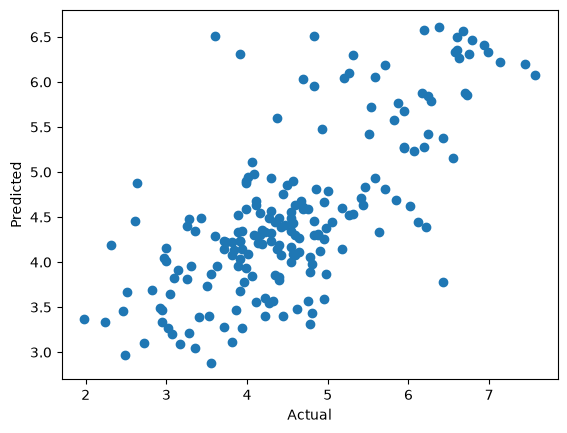

In [69]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

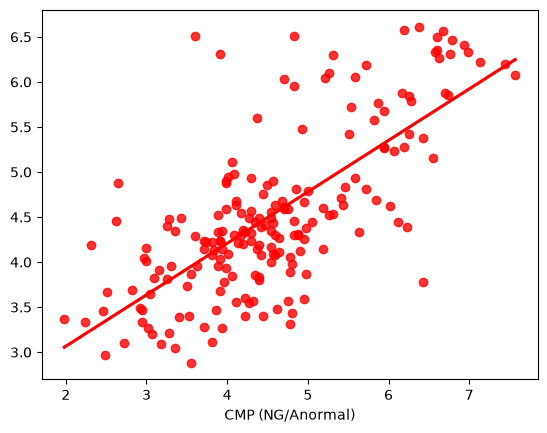

In [70]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [71]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
1100,4.2164,3.402584,0.813816
546,2.6162,4.457446,-1.841246
201,5.5118,5.425440,0.086360
471,6.1214,4.448556,1.672844
79,5.4610,4.837684,0.623316
...,...,...,...
1190,4.9022,4.127246,0.774954
252,3.6068,6.510528,-2.903728
662,3.2766,3.212846,0.063754
39,4.4704,4.417314,0.053086


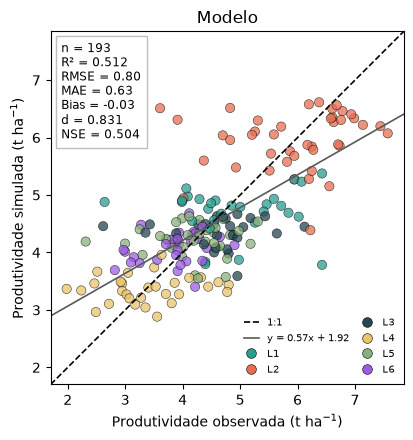

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- dados ----------
obs = np.asarray(y_test, dtype=float)
sim = np.asarray(y_pred, dtype=float).ravel()
idx = y_test.index

lote = df.loc[idx, 'Lote']

cores = {
    'L1': '#2A9D8F',
    'L2': '#E76F51',
    'L3': '#264653',
    'L4': '#E9C46A',
    'L5': '#8AB17D',
    'L6': '#9B5DE5',
}
c = lote.map(cores).fillna('#BBBBBB').to_numpy()

# ---------- métricas ----------
res  = sim - obs
rmse = np.sqrt(np.mean(res**2))
mae  = np.mean(np.abs(res))
bias = np.mean(res)
r    = np.corrcoef(sim, obs)[0, 1]
d    = 1 - np.sum(res**2) / np.sum((np.abs(sim - obs.mean()) + np.abs(obs - obs.mean()))**2)
nse  = 1 - np.sum(res**2) / np.sum((obs - obs.mean())**2)

# ---------- figura ----------
fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(obs, sim, s=45, c=c, edgecolor='k', linewidth=0.4, alpha=0.75)

lo, hi = min(obs.min(), sim.min()), max(obs.max(), sim.max())
pad = 0.05 * (hi - lo)
lim = [lo - pad, hi + pad]

l_11, = ax.plot(lim, lim, color='black', linestyle='--', lw=1.2, label='1:1')

b, a = np.polyfit(obs, sim, 1)
l_fit, = ax.plot(lim, np.polyval([b, a], lim), '-', color='0.35', lw=1.2,
                 label=f'y = {b:.2f}x + {a:.2f}')

ax.set(xlim=lim, ylim=lim, aspect='equal',
       xlabel='Produtividade observada (t ha$^{-1}$)',
       ylabel='Produtividade simulada (t ha$^{-1}$)',
       title='Modelo')

txt = (f'n = {len(obs)}\nR² = {r**2:.3f}\nRMSE = {rmse:.2f}\n'
       f'MAE = {mae:.2f}\nBias = {bias:+.2f}\nd = {d:.3f}\nNSE = {nse:.3f}')
ax.text(0.03, 0.97, txt, transform=ax.transAxes, va='top', ha='left',
        fontsize=8.5, bbox=dict(fc='white', ec='0.7', alpha=0.85, pad=4))

# ---------- legenda ----------
handles_lote = [Line2D([], [], marker='o', ls='', mfc=v, mec='k', mew=0.4,
                       ms=7, label=str(k)) for k, v in cores.items()]
ax.legend(handles=[l_11, l_fit] + handles_lote,
          loc='lower right', frameon=False, fontsize=7.5, ncol=2,
          handlelength=1.4, columnspacing=1.0)

fig.tight_layout()
plt.show()

In [73]:
lote

1100    L6
546     L3
201     L2
471     L3
79      L1
        ..
1190    L6
252     L2
662     L4
39      L1
37      L1
Name: Lote, Length: 193, dtype: str